In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('data/rain_data/train.csv')
test = pd.read_csv('data/rain_data/train.csv')

print(train.shape, train.dtypes, train.head())

(2190, 13) id                 int64
day                int64
pressure         float64
maxtemp          float64
temparature      float64
mintemp          float64
dewpoint         float64
humidity         float64
cloud            float64
sunshine         float64
winddirection    float64
windspeed        float64
rainfall           int64
dtype: object    id  day  pressure  maxtemp  temparature  mintemp  dewpoint  humidity  \
0   0    1    1017.4     21.2         20.6     19.9      19.4      87.0   
1   1    2    1019.5     16.2         16.9     15.8      15.4      95.0   
2   2    3    1024.1     19.4         16.1     14.6       9.3      75.0   
3   3    4    1013.4     18.1         17.8     16.9      16.8      95.0   
4   4    5    1021.8     21.3         18.4     15.2       9.6      52.0   

   cloud  sunshine  winddirection  windspeed  rainfall  
0   88.0       1.1           60.0       17.2         1  
1   91.0       0.0           50.0       21.9         1  
2   47.0       8.3          

In [3]:
print(train.isnull().sum().sort_values(ascending=False))
print(f'Missed {train.isnull().sum().sum()}')

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64
Missed 0


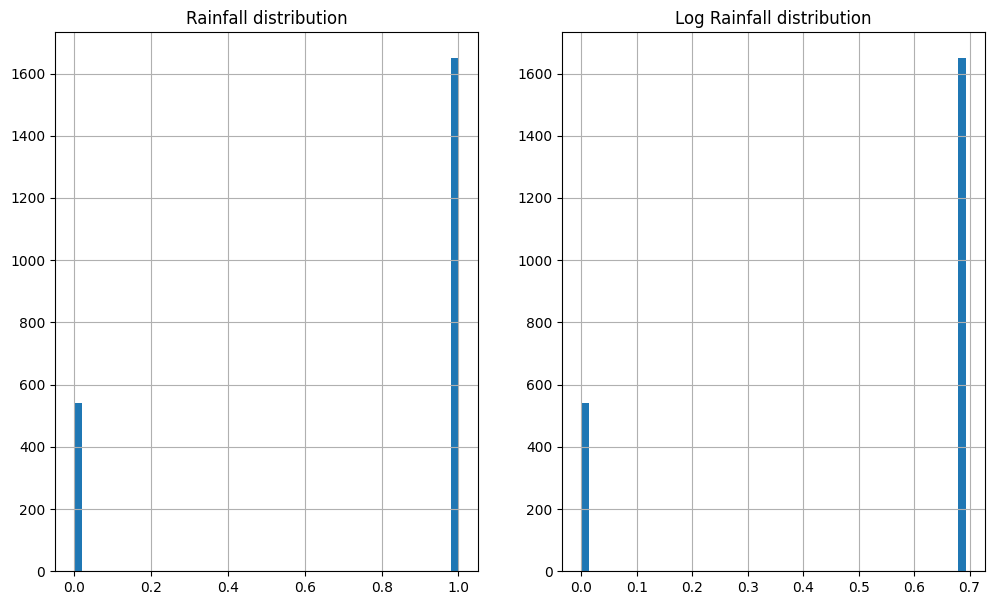

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,7))
train['rainfall'].hist(bins=50, ax=axes[0])
axes[0].set_title('Rainfall distribution')
np.log1p(train['rainfall']).hist(bins=50, ax=axes[1])
axes[1].set_title('Log Rainfall distribution')
plt.show()

In [5]:
corr = train.corr()['rainfall'].sort_values(ascending=False)
print(corr)

rainfall         1.000000
cloud            0.641191
humidity         0.454213
windspeed        0.111625
dewpoint         0.081965
id               0.033674
day             -0.000462
winddirection   -0.006939
mintemp         -0.026841
temparature     -0.049660
pressure        -0.049886
maxtemp         -0.079304
sunshine        -0.555287
Name: rainfall, dtype: float64


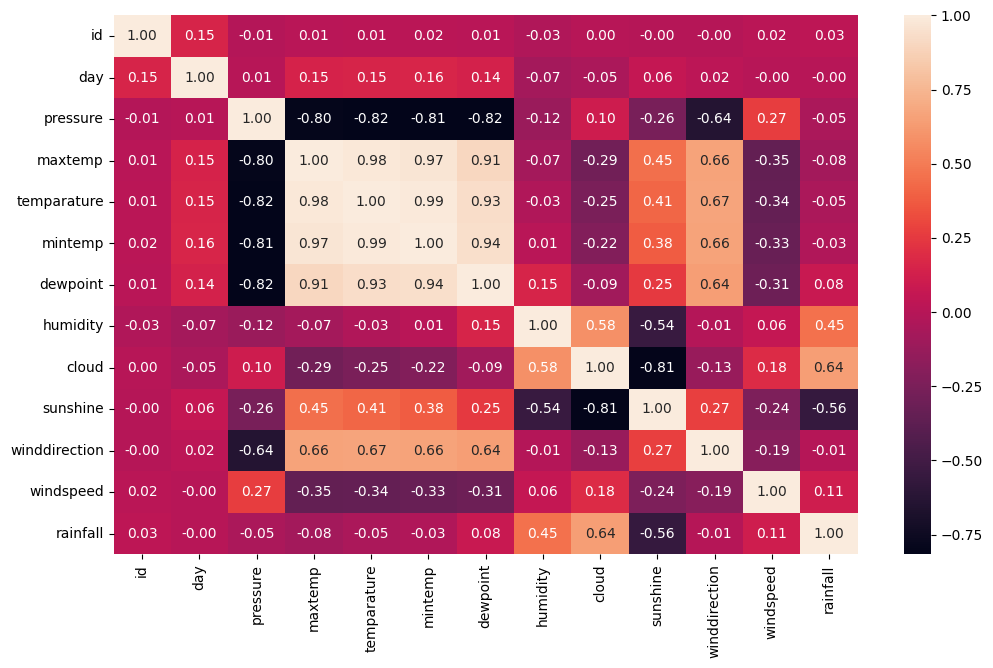

In [6]:
plt.figure(figsize=(12,7))
sns.heatmap(train.corr(), annot=True, fmt='.2f')
plt.show()

In [10]:
train['temp_range'] = train['maxtemp'] - train['mintemp']

train['dewpoint_diff'] = train['temparature'] - train['dewpoint']

train['cloud_humidity'] = train['cloud'] * train['humidity']

train['discomfort'] = train['temparature'] - 0.55 * (1 - train['humidity']/100) * (train['temparature'] - 14)

train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,temp_range,dewpoint_diff,cloud_humidity,discomfort
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1,1.3,1.2,7656.0,20.12810
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1,0.4,1.5,8645.0,16.82025
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1,4.8,6.8,3525.0,15.81125
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1,1.2,1.0,9025.0,17.69550
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0,6.1,8.8,2340.0,17.23840


In [12]:
print(train['rainfall'].value_counts())
print(train['rainfall'].value_counts(normalize=True))

rainfall
1    1650
0     540
Name: count, dtype: int64
rainfall
1    0.753425
0    0.246575
Name: proportion, dtype: float64


In [13]:
from sklearn.model_selection import train_test_split

features = [col for col in train.columns if col not in['id', 'rainfall']]
X = train[features]
y = train['rainfall']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from xgboost import XGBClassifier
import lightgbm as lgb

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=28),
    'XGBoost': XGBClassifier(random_state=28, eval_metrics='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=28)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, pred)
    roc = roc_auc_score(y_test, pred_prob)
    results[name] = {'Accuracy': acc, 'ROC-AUC': roc}
    print(f'\n{name}')
    print(f'Accuracy: {acc:.3f}, ROC: {roc:.3f}')
    print(classification_report(y_test, pred))

pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)

D:\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



LogisticRegression
Accuracy: 0.861, ROC: 0.880
              precision    recall  f1-score   support

           0       0.77      0.62      0.69       108
           1       0.88      0.94      0.91       330

    accuracy                           0.86       438
   macro avg       0.83      0.78      0.80       438
weighted avg       0.86      0.86      0.86       438


RandomForest
Accuracy: 0.879, ROC: 0.872
              precision    recall  f1-score   support

           0       0.81      0.67      0.73       108
           1       0.90      0.95      0.92       330

    accuracy                           0.88       438
   macro avg       0.85      0.81      0.83       438
weighted avg       0.88      0.88      0.87       438


XGBoost
Accuracy: 0.840, ROC: 0.840
              precision    recall  f1-score   support

           0       0.71      0.59      0.65       108
           1       0.87      0.92      0.90       330

    accuracy                           0.84       438
 

D:\ml_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:08:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



LightGBM
Accuracy: 0.842, ROC: 0.854
              precision    recall  f1-score   support

           0       0.72      0.59      0.65       108
           1       0.87      0.92      0.90       330

    accuracy                           0.84       438
   macro avg       0.80      0.76      0.77       438
weighted avg       0.84      0.84      0.84       438



,Accuracy,ROC-AUC
LogisticRegression,0.860731,0.879994
RandomForest,0.878995,0.872152
LightGBM,0.842466,0.853788
XGBoost,0.840183,0.840208


In [28]:
import optuna 

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': 28,
        'eval_metric': 'logloss',
    }

    model = XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    
    pred_prob = model.predict_proba(X_test)[:,1]
    return roc_auc_score(y_test, pred_prob)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f'Best ROC-AUC: {study.best_value:.3f}')
print(f'Best Params: {study.best_params}')

  0%|          | 0/200 [00:00<?, ?it/s]

Best ROC-AUC: 0.888
Best Params: {'n_estimators': 119, 'max_depth': 6, 'learning_rate': 0.01439927436636732, 'subsample': 0.6185733804614113, 'colsample_bytree': 0.6941448299796298, 'min_child_weight': 6, 'gamma': 4.55063173407354, 'reg_alpha': 1.377668226127271e-06, 'reg_lambda': 0.03177995651333403}


In [29]:
def objective_lgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': 42,
        'verbose': -1,
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)

    pred_prob = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, pred_prob)

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=200, show_progress_bar=True)

print(f'LightGBM ROC-AUC: {study_lgb.best_value:.4f}')

  0%|          | 0/200 [00:00<?, ?it/s]

LightGBM ROC-AUC: 0.8852


In [32]:
best_xgb = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
best_xgb.fit(X_train, y_train)
pred_prob = best_xgb.predict_proba(X_test)[:, 1]
print(f'Final ROC-AUC: {roc_auc_score(y_test, pred_prob):.4f}')

best_lgb = lgb.LGBMClassifier(**study_lgb.best_params, random_state=28)
best_lgb.fit(X_train, y_train)
pred_prob = best_lgb.predict_proba(X_test)[:, 1]
print(f'Final ROC-AUC: {roc_auc_score(y_test, pred_prob):.4f}')

Final ROC-AUC: 0.8855
Final ROC-AUC: 0.8852
